## Загрузка данных


In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import locale
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression


In [36]:
df = pd.read_csv("Dt.csv")
df.head(50)

,date,monthly_sales
0,2021-01-31,95799.45
1,2021-02-28,107537.77
2,2021-03-31,110276.15
3,2021-04-30,118061.86
4,2021-05-31,118234.89
5,2021-06-30,118989.48
6,2021-07-31,106032.93
7,2021-08-31,107523.68
8,2021-09-30,96311.30
9,2021-10-31,99141.87


In [37]:
infdf = df.info()
print("_"*50)
print(df.shape)

<class 'pandas.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           36 non-null     str    
 1   monthly_sales  36 non-null     float64
dtypes: float64(1), str(1)
memory usage: 708.0 bytes
__________________________________________________
(36, 2)


In [38]:
indf = df.isnull().sum().reset_index()
print(indf)
print('_'*50)
print(df.shape)

           index  0
0           date  0
1  monthly_sales  0
__________________________________________________
(36, 2)


#### пропусков нет

In [39]:
df = df.drop_duplicates()
print(df.shape)

(36, 2)


#### дубликовтов нет так как данных мало и при удалинии дубликатов колво данных не поменялось

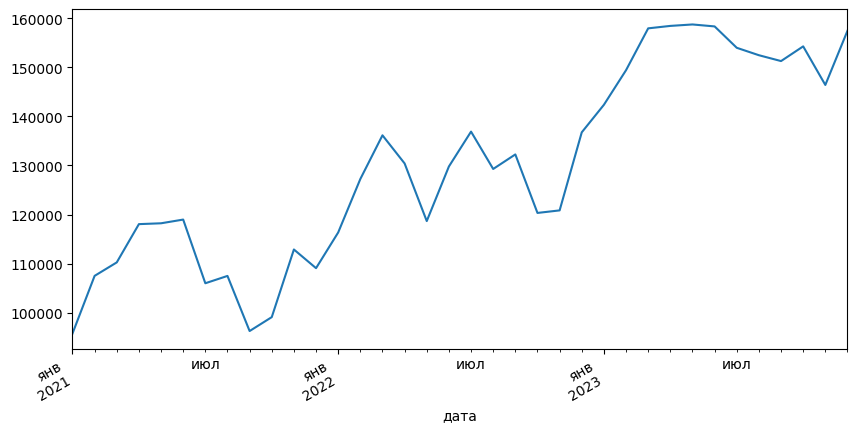

In [40]:
locale.setlocale(locale.LC_TIME, 'Russian_Russia')

df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date')
df.index.name = 'дата'

df['monthly_sales'].plot(figsize=(10,5))
plt.gcf().autofmt_xdate()
plt.show()

<Axes: xlabel='month'>

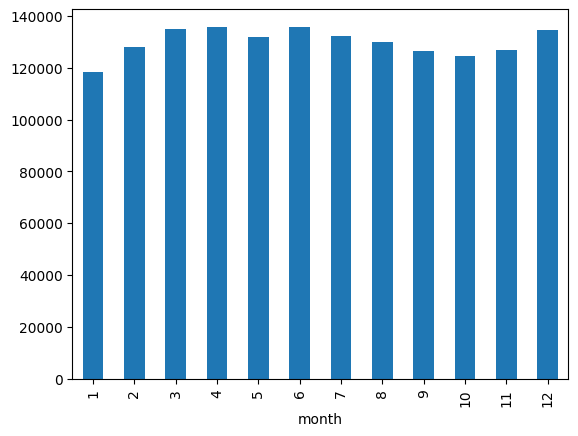

In [41]:
df['month'] = df.index.month
df.groupby('month')['monthly_sales'].mean().plot(kind='bar')

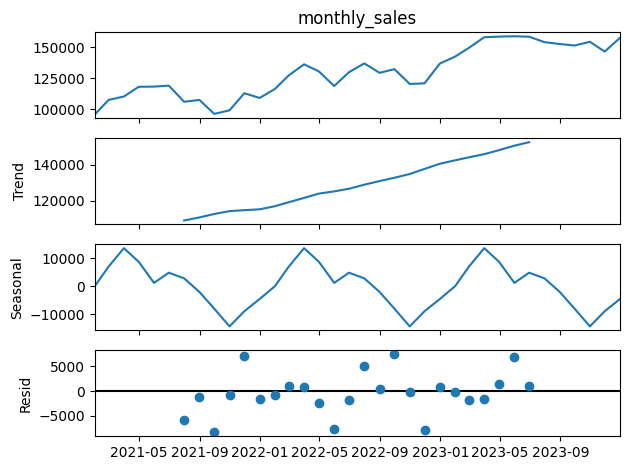

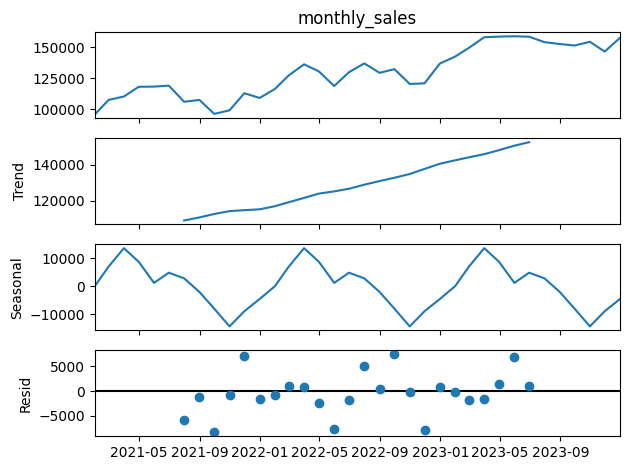

In [42]:
result = seasonal_decompose(df['monthly_sales'], period=12)
result.plot()

#### да сезонность есть ее видно по 3 графиком и тренд идет в верх тоеть рост продаж есть и идет в верх каждый год

# Реализация моделей


#### Делим данные для обучения и проверки темболее надо показать в задании как предсказывет моделька тоеть надо узнать ее точность на тестовых данных


C:\Users\josha\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
C:\Users\josha\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
C:\Users\josha\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
C:\Users\josha\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\Local


Polynomial
MAE: 18340.44
MSE: 373702976.23
RMSE: 19331.40
MAPE: 12.02%

RandomForest
MAE: 4063.77
MSE: 26500166.15
RMSE: 5147.83
MAPE: 2.70%

ARIMA
MAE: 3974.14
MSE: 28850396.57
RMSE: 5371.26
MAPE: 2.57%

Linear
MAE: 3402.56
MSE: 15912304.12
RMSE: 3989.02
MAPE: 2.24%


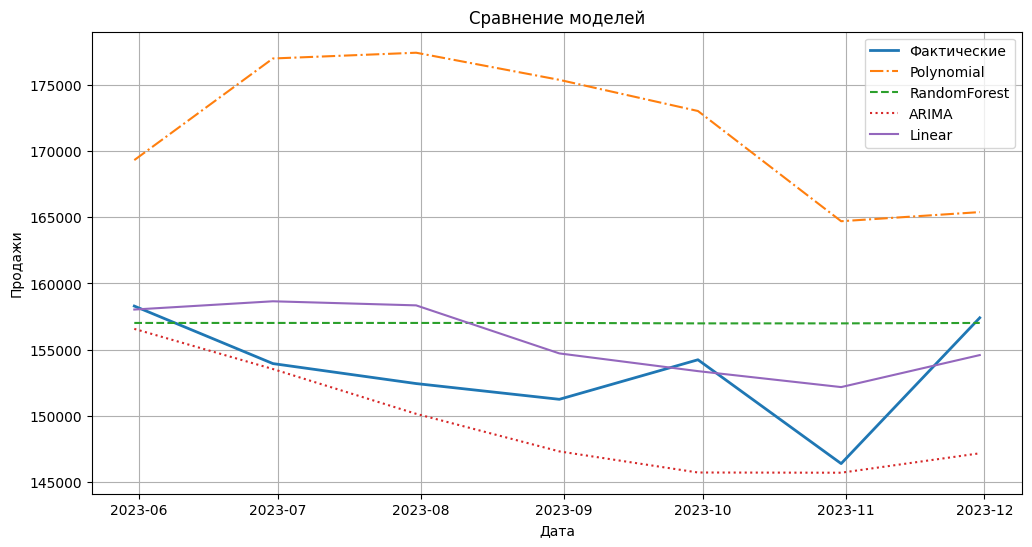

In [43]:
df2 = df.copy()

df2['lag1'] = df2['monthly_sales'].shift(1)
df2['lag2'] = df2['monthly_sales'].shift(2)
df2['lag3'] = df2['monthly_sales'].shift(3)

df2['rolling_mean'] = df2['monthly_sales'].shift(1).rolling(3).mean()
df2['target'] = df2['monthly_sales'].shift(-1)

df2 = df2.dropna()

train_size = int(len(df2) * 0.8)

tr = df2.iloc[:train_size]
ts = df2.iloc[train_size:]

features = ['lag1', 'lag2', 'lag3', 'rolling_mean']

X_train = tr[features]
X_test = ts[features]

y_train = tr['target']
y_test = ts['target']


poly = PolynomialFeatures(degree=2)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

model_poly = LinearRegression()
model_poly.fit(X_train_poly, y_train)

y_pred_poly = model_poly.predict(X_test_poly)

model_arima = ARIMA(tr['monthly_sales'], order=(2,1,2))
model_arima_fit = model_arima.fit()

y_pred_arima = model_arima_fit.forecast(steps=len(ts))

model_rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=6,
    random_state=42
)

model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)

model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

y_pred_lr = model_lr.predict(X_test)



def print_metrics(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100

    print(f"\n{name}")
    print(f"MAE: {mae:.2f}")
    print(f"MSE: {mse:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAPE: {mape:.2f}%")


print_metrics("Polynomial", y_test, y_pred_poly)
print_metrics("RandomForest", y_test, y_pred_rf)
print_metrics("ARIMA", y_test, y_pred_arima)
print_metrics("Linear", y_test, y_pred_lr)



plt.figure(figsize=(12,6))

plt.plot(ts.index, y_test, label='Фактические', linewidth=2)

plt.plot(ts.index, y_pred_poly, label='Polynomial', linestyle='-.')
plt.plot(ts.index, y_pred_rf, label='RandomForest', linestyle='--')
plt.plot(ts.index, y_pred_arima, label='ARIMA', linestyle=':')
plt.plot(ts.index, y_pred_lr, label='Linear', linestyle='-')

plt.title('Сравнение моделей')
plt.xlabel('Дата')
plt.ylabel('Продажи')

plt.legend()
plt.grid()

plt.show()


### Модели точно можно улучшить они предсказывают достаточно неплохо на тестовых данных, но можно лучше. Для этого нужно больше данных и больше признаков колонок, которые помогали бы модели за счёт каких-то дополнительных вводных.
